# Analyse Exploratoire des Clients Olist


Ce notebook vise à explorer les comportements des clients d'Olist afin de construire une segmentation utile pour les campagnes marketing.

Nous allons :
- Créer des variables pertinentes centrées sur le client
- Étudier les relations entre ces variables
- Visualiser les données
- Préparer un clustering


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import numpy as np
from tqdm import tqdm

sns.set(style="whitegrid")


## Chargement des données client

In [ ]:
df = pd.read_csv("df_clients.csv")
del df['taux_avis']
df.head()

,Unnamed: 0,identifiant_unique_client,nombre_commandes,montant_total_acheté,panier_moyen,note_moyenne,types_paiement_utilisés,paiement_en_plusieurs_fois,moyenne_nbre_paiements,variete_categories,dernier_achat,premier_achat,etat_client,code_postal_client,recence,anciennete,frequence_commande_mensuelle,jours_entre_commandes_moyen
0,0,0000366f3b9a7992bf8c76cfdf3221e2,1,141.90,141.90,5.0,1,1.0,8.0,1,2018-05-10,2018-05-10,São Paulo,7787,116,1,30.0,1.0
1,1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,27.19,27.19,4.0,1,0.0,1.0,1,2018-05-07,2018-05-07,São Paulo,6053,119,1,30.0,1.0
2,2,0000f46a3911fa3c0805444483337064,1,86.22,86.22,3.0,1,1.0,8.0,1,2017-03-10,2017-03-10,Santa Catarina,88115,542,1,30.0,1.0
3,3,0000f6ccb0745a6a4b88665a16c9f078,1,43.62,43.62,4.0,1,1.0,4.0,1,2017-10-12,2017-10-12,Pará,66812,326,1,30.0,1.0
4,4,0004aac84e0df4da2b147fca70cf8255,1,196.89,196.89,5.0,1,1.0,6.0,1,2017-11-14,2017-11-14,São Paulo,18040,293,1,30.0,1.0


## Statistiques descriptives

In [ ]:
df.describe(include='all')

,Unnamed: 0,identifiant_unique_client,nombre_commandes,montant_total_acheté,panier_moyen,note_moyenne,types_paiement_utilisés,paiement_en_plusieurs_fois,moyenne_nbre_paiements,variete_categories,dernier_achat,premier_achat,etat_client,code_postal_client,recence,anciennete,frequence_commande_mensuelle,jours_entre_commandes_moyen
count,94720.000000,94720,94720.000000,94720.000000,94720.000000,94720.000000,94720.000000,94720.000000,94720.000000,94720.000000,94720,94720,94720,94720.000000,94720.000000,94720.000000,94720.000000,94720.000000
unique,NaN,94720,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,614,614,27,NaN,NaN,NaN,NaN,NaN
top,NaN,0000366f3b9a7992bf8c76cfdf3221e2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017-11-24,2017-11-24,São Paulo,NaN,NaN,NaN,NaN,NaN
freq,NaN,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1123,1124,39720,NaN,NaN,NaN,NaN,NaN
mean,47359.500000,NaN,1.033742,208.787789,158.333719,4.102233,1.003980,0.510018,2.903117,1.020481,NaN,NaN,NaN,35222.516512,243.338967,3.668402,29.677218,2.239686
std,27343.453086,NaN,0.210529,623.844834,217.664768,1.327111,0.063464,0.498507,2.686337,0.149757,NaN,NaN,NaN,29825.570966,153.164273,25.246478,5.024937,11.859332
min,0.000000,NaN,1.000000,0.010000,0.010000,1.000000,1.000000,0.000000,0.000000,1.000000,NaN,NaN,NaN,1003.000000,0.000000,1.000000,0.098361,0.166667
25%,23679.750000,NaN,1.000000,62.170000,60.590000,4.000000,1.000000,0.000000,1.000000,1.000000,NaN,NaN,NaN,11410.000000,119.000000,1.000000,30.000000,1.000000
50%,47359.500000,NaN,1.000000,111.020000,103.750000,5.000000,1.000000,1.000000,2.000000,1.000000,NaN,NaN,NaN,24445.000000,224.000000,1.000000,30.000000,1.000000
75%,71039.250000,NaN,1.000000,199.070000,175.280000,5.000000,1.000000,1.000000,4.000000,1.000000,NaN,NaN,NaN,59068.250000,353.000000,1.000000,30.000000,1.000000


## Visualisation des variables clés

C:\Users\abapst\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


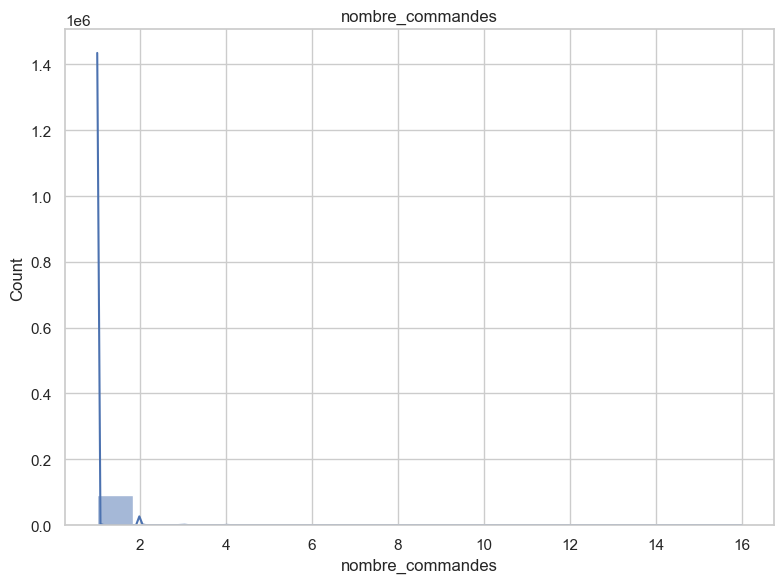

C:\Users\abapst\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


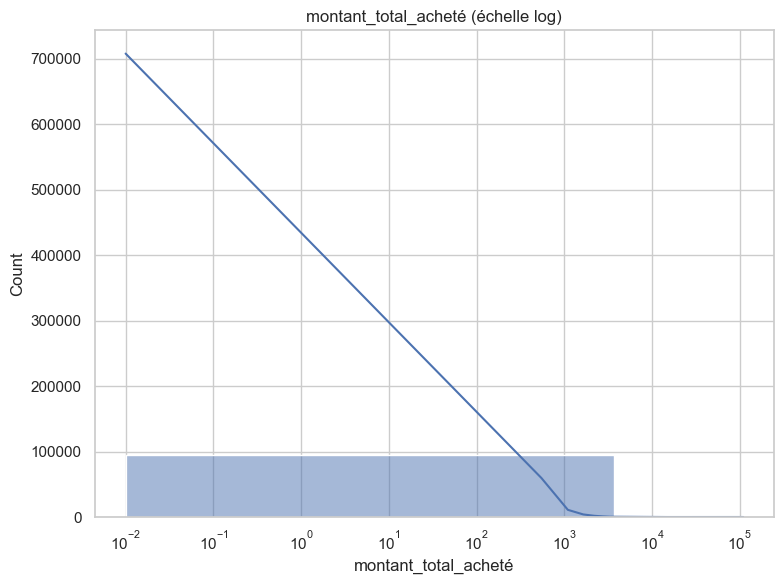

C:\Users\abapst\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


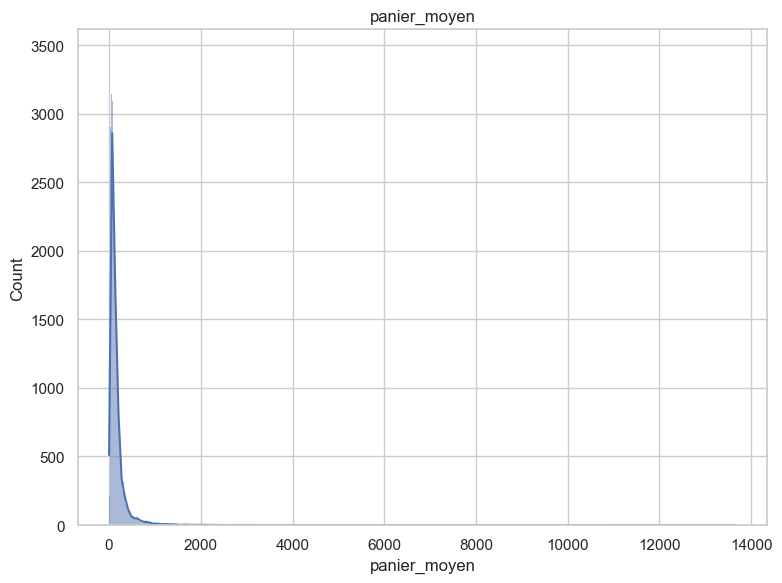

C:\Users\abapst\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


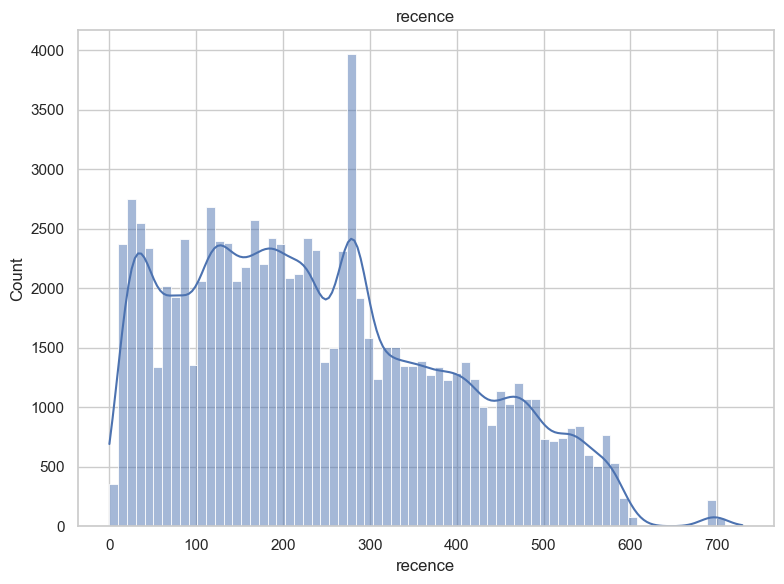

C:\Users\abapst\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


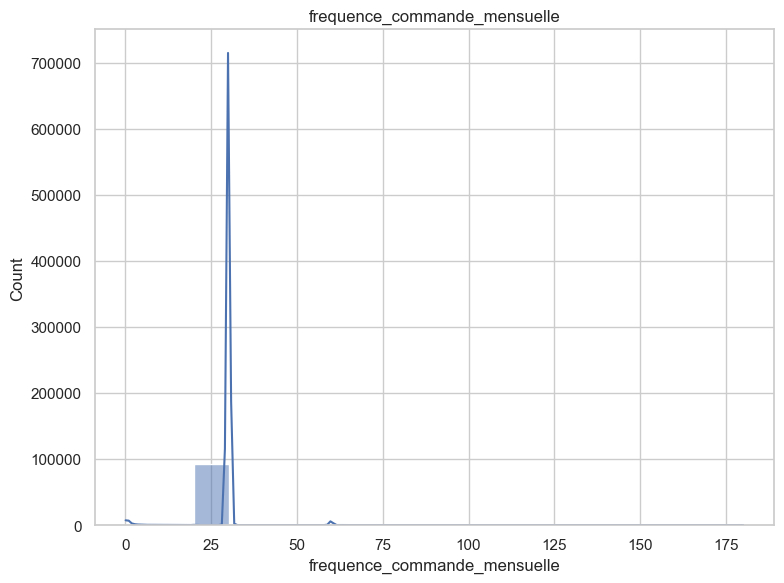

C:\Users\abapst\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


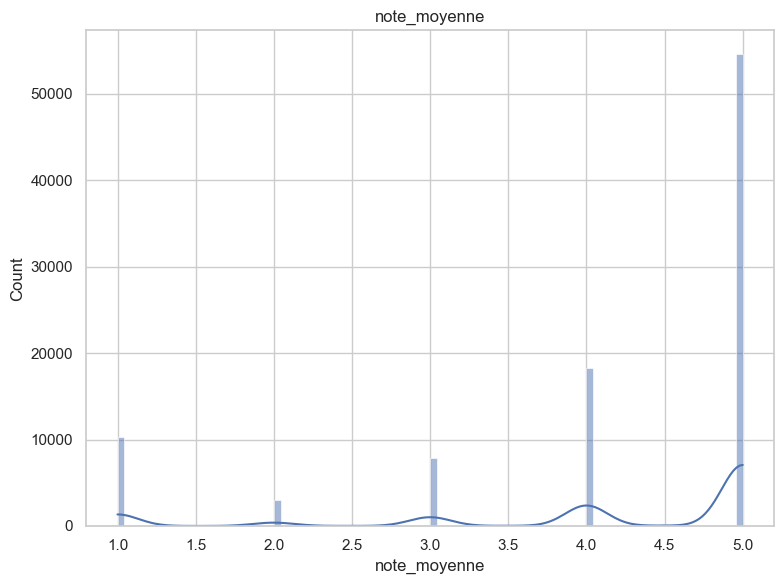

C:\Users\abapst\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


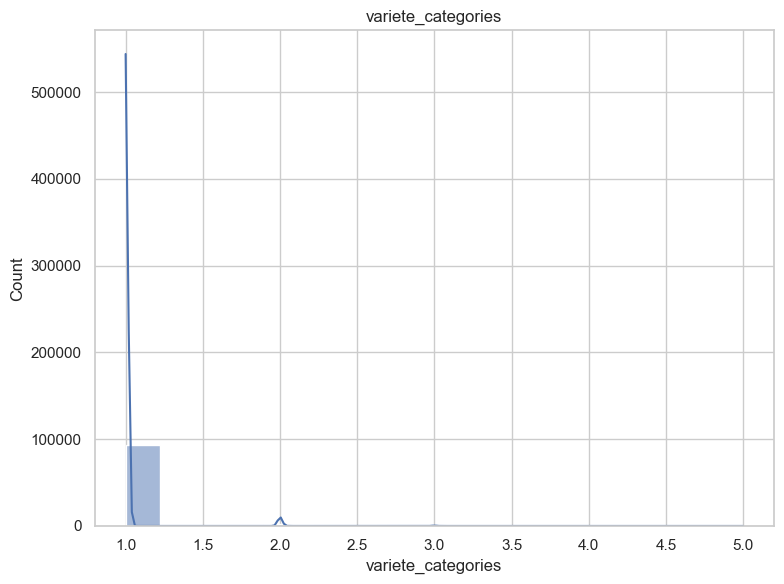

C:\Users\abapst\AppData\Local\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


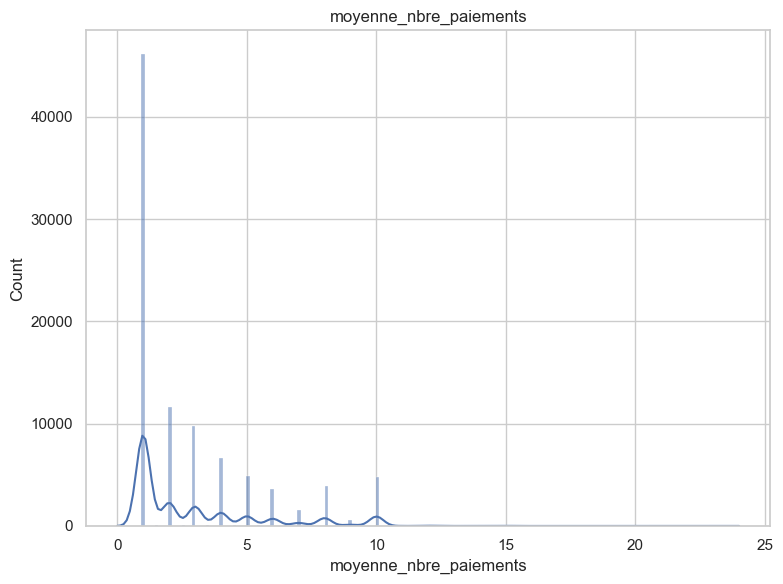

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

variables = ['nombre_commandes', 'montant_total_acheté', 'panier_moyen',
             'recence', 'frequence_commande_mensuelle', 'note_moyenne',
             'variete_categories', 'moyenne_nbre_paiements']

for var in variables:
    plt.figure(figsize=(8, 6))
    data = df[var].dropna()

    if var == 'montant_total_acheté':
        data = data[data > 0]  # enlever 0 ou négatifs pour log
        sns.histplot(data, kde=True, bins=30)
        plt.xscale('log')
        plt.title(f"{var} (échelle log)")
    else:
        sns.histplot(data, kde=True)
        plt.title(var)

    plt.tight_layout()
    plt.show()


## Corrélation entre les variables

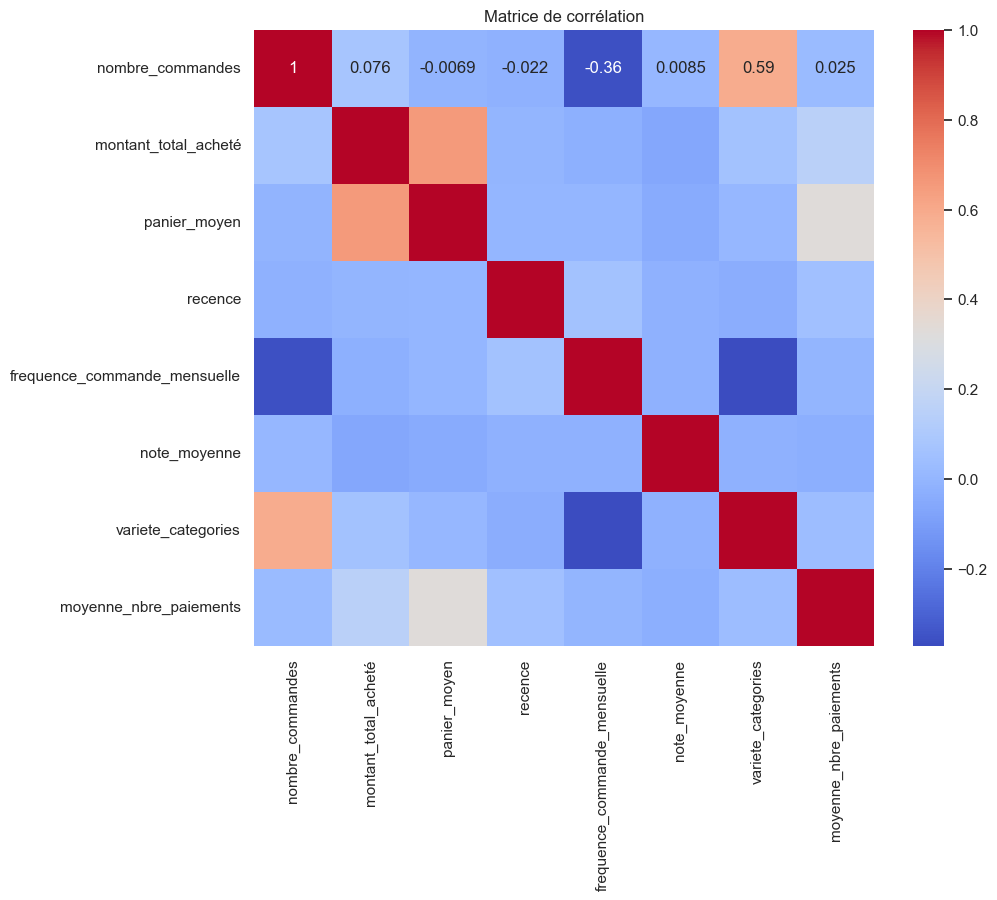

In [ ]:
plt.figure(figsize=(10,8))
corr = df[variables].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Matrice de corrélation")
plt.show()


## Standardisation des données

In [ ]:

features = df[variables].fillna(0)  # On remplace les NaN par 0 ici par simplicité
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)


## Réduction de dimension (PCA)

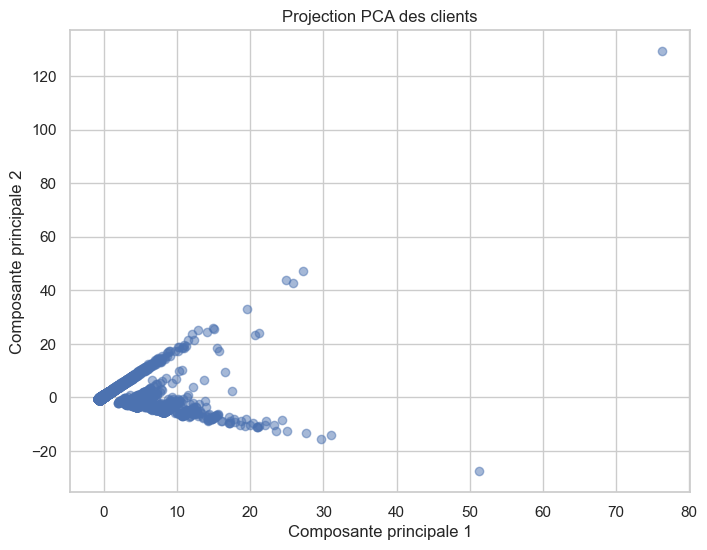

In [ ]:

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], alpha=0.5)
plt.title("Projection PCA des clients")
plt.xlabel("Composante principale 1")
plt.ylabel("Composante principale 2")
plt.show()


## Clustering KMeans avec évaluation

Clustering KMeans: 100%|██████████| 6/6 [10:29<00:00, 104.87s/it]


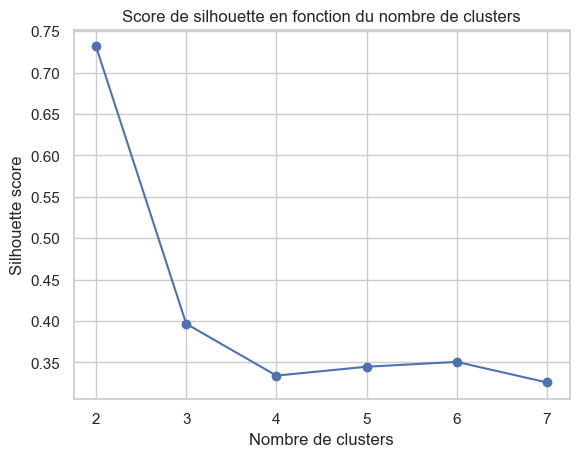

In [ ]:

silhouette_scores = []
for k in tqdm(range(2, 8), desc="Clustering KMeans"):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)

plt.plot(range(2, 8), silhouette_scores, marker='o')
plt.title("Score de silhouette en fonction du nombre de clusters")
plt.xlabel("Nombre de clusters")
plt.ylabel("Silhouette score")
plt.show()


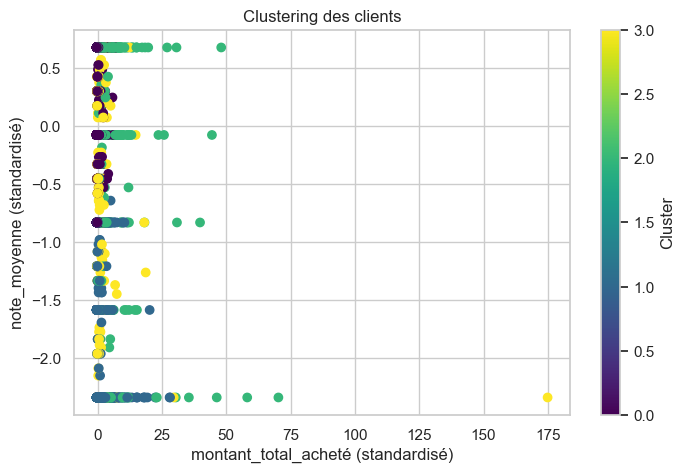

cluster
0    61702
2    16428
1    14953
3     1637
Name: count, dtype: int64


In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt
from datetime import datetime


df = pd.read_csv("df_clients.csv")

# Sélection des colonnes de features
features = df[[
    "montant_total_acheté",
    "note_moyenne",
    "variete_categories",
    "moyenne_nbre_paiements",
    "frequence_commande_mensuelle"
]].fillna(0)

# Standardisation
scaler = StandardScaler()
X_scaled = scaler.fit_transform(features)

# Clustering
kmeans = KMeans(n_clusters=4, random_state=42)
labels = kmeans.fit_predict(X_scaled)

# Ajout des labels au DataFrame
df["cluster"] = labels

# Visualisation (exemple avec 2 axes)
plt.figure(figsize=(8, 5))
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=labels, cmap="viridis")
plt.xlabel("montant_total_acheté (standardisé)")
plt.ylabel("note_moyenne (standardisé)")
plt.title("Clustering des clients")
plt.colorbar(label="Cluster")
plt.show()

# Nombre de clients par cluster
print(df["cluster"].value_counts())

